Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Exercício 3: MLP

Implemente uma rede neural e utilize o treinamento com o algoritmo de retropropagação para modelar as seguintes funções:

a) $\displaystyle f(x) = \frac{1}{x},\;\; 1\le x \le 100$

b) $f(x) = {\rm log}_{10}x,\;\; 1\le x \le 10$

c) $f(x) = {\rm exp}(-x),\;\; 1\le x \le 10$

d) $\displaystyle f(x) = {\rm sen}(x),\;\; 0\le x \le \frac{\pi}{2}$

e) $f(x,y)=\sin(x)\cos(y),\;\; (x,y)\in[-2\pi,2\pi]\times[-2\pi,2\pi]$


- Implemente uma rede neural com um número variável de entradas, um número variável de neurônios na camada oculta e uma saída. Para tanto, uma sugestão é implementar duas funções:
  - *Treinamento*, que recebe o sinal de entrada, o passo de adaptação, o número de épocas e o número de neurônios da camada oculta e retorna os pesos da rede treinada e um sinal com o valor da função custo ao longo das épocas;
  - *Inferência*: que recebe os pesos da rede, o número de neurônios na camada oculta (também poderia obter essa informação a partir dos pesos) e uma entrada e retorna a saída da rede.
- Sugestão: modifique o código da Aula 4 (implementado para um rede com 2 neurônios na camada oculta e 1 neurônio de saída) para possibilitar treinar uma rede com N (informado pelo usuário) neurônios na camada oculta. **Não utilize o código da Aula 5. Quem utilizar esse código terá nota zero no exercício**;
- Utilize uma função sigmoidal como função de ativação para os neurônios da camada oculta e da camada de saída (note que as funções sempre retornam valores entre 0 e 1 nos intervalos indicados);
- Faça a implementação **usando apenas vetores, tensores e operações aritméticas**, sem utilizar recursos de *frameworks* para redes neurais como Keras ou PyTorch;
- Crie dois conjuntos de dados, um deles para treinamento da rede e outro para o teste. Considere entre 1000 a 10000 pontos para treinamento e 1000 para teste;
- Avalie o desempenho da rede para cada caso, calculando o erro quadrático médio obtido no conjunto de teste e plotando gráficos da funções e das aproximações obtidas com a rede, considerando os seguintes números de neurônios na camada oculta: 3, 4, 5, 10, 15, 20, 50, 100.

Ao final do exercício, você deverá apresentar:

1. Os códigos utilizados para treinar e fazer a inferência com os seus modelos;

2. Um conjunto de gráficos das aproximações obtidas para cada função usando dados de teste, com os diferentes números de neurônios na camada oculta. Para o item e), que consiste em uma função de duas entradas, plote dois gráficos para cada configuração de neurônios na camada oculta, um deles considerando $x = 0$ fixo e variando $y$ e o outro considerando $y=0$ fixo e variando $x$;

3. Uma tabela com o erro quadrático médio obtido no teste, para cada função, com diferentes números de neurônios na camada oculta.

A sugestão é que o relatório seja elaborado utilizando um Jupyter Notebook e a linguagem Python, já que essas são as ferramentas que estamos utilizando neste bloco do curso. No entanto, isso não é obrigatório e você pode usar outra linguagem de programação, caso queira.

## Instruções para entrega

- O exercício pode ser feito em dupla ou individualmente;

- A entrega deve incluir:
  - Um vídeo de no **máximo 40s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados.

- **A correção será feita baseada no vídeo**. Quando o professor/pesquisador ficar com alguma dúvida, serão consultados os códigos-fonte;

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - No caso de entrega em dupla, **não é necessário que os dois componentes apareçam no vídeo**. No entanto, alternem o apresentador ao longo das entregas dos exercícios e **não esqueçam de incluir os dois nomes no início do vídeo**.
  - Procurem convencer o espectador do vídeo, que vai corrigir o exercício que fizeram os exercícios computacionais solicitados e que eles estão funcionando corretamente. Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 40s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do(s) aluno(s)** no início do programa;

- Sobre o envio no Moodle:
  - Apenas um aluno de cada dupla deve enviar o vídeo no Moodle;
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br, renatocan@lps.usp.br, wesleybeccaro@usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome dos componentes da dupla (ou do único aluno, escrevendo: "exercício feito individualmente") em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.



In [3]:
# Célula 1: Importações e funções de ativação
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Função de ativação Sigmoide e sua derivada
def sigmoid(x):
    # O np.clip evita overflow no exp
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

# Dicionário para armazenar o Erro Quadrático Médio de todas as configurações
resultados_eqm = {}

In [4]:
# Célula 2: Funções Treinamento e Inferência
def Treinamento(X, Y, eta, epochs, N):
    """
    X: matriz de entradas (n_amostras, n_features)
    Y: matriz de saídas esperadas (n_amostras, 1)
    eta: taxa de aprendizado (passo de adaptação)
    epochs: número de épocas
    N: número de neurônios na camada oculta
    """
    n_amostras, n_entradas = X.shape
    _, n_saidas = Y.shape

    # Inicialização aleatória dos pesos e viés (usando distribuição normal com desvio padrão pequeno)
    np.random.seed(42)
    W1 = np.random.randn(n_entradas, N) * 0.1
    b1 = np.zeros((1, N))
    W2 = np.random.randn(N, n_saidas) * 0.1
    b2 = np.zeros((1, n_saidas))

    historico_custo = []

    for epoch in range(epochs):
        # --- Forward Pass (Propagação) ---
        Z1 = np.dot(X, W1) + b1
        A1 = sigmoid(Z1)

        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)

        # Cálculo do erro (Custo: Erro Quadrático Médio)
        erro = Y - A2
        custo = np.mean(erro ** 2)
        historico_custo.append(custo)

        # --- Backward Pass (Retropropagação) ---
        # Gradiente da camada de saída
        # Derivada do MSE em relação a A2 * Derivada da Sigmoide em Z2
        # (O sinal negativo do erro já dita a direção da soma na atualização)
        dA2 = erro * d_sigmoid(Z2)

        dW2 = np.dot(A1.T, dA2) / n_amostras
        db2 = np.sum(dA2, axis=0, keepdims=True) / n_amostras

        # Gradiente da camada oculta
        dA1 = np.dot(dA2, W2.T) * d_sigmoid(Z1)

        dW1 = np.dot(X.T, dA1) / n_amostras
        db1 = np.sum(dA1, axis=0, keepdims=True) / n_amostras

        # --- Atualização dos Pesos ---
        # Somamos o gradiente porque 'erro' foi definido como (Y - A2).
        # Se fosse (A2 - Y), faríamos W -= eta * dW
        W1 += eta * dW1
        b1 += eta * db1
        W2 += eta * dW2
        b2 += eta * db2

    pesos = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
    return pesos, historico_custo

def Inferencia(pesos, X):
    """
    Recebe os pesos treinados e a entrada, retorna a previsão.
    A quantidade de neurônios da camada oculta está implícita no shape dos pesos.
    """
    W1, b1, W2, b2 = pesos['W1'], pesos['b1'], pesos['W2'], pesos['b2']

    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return A2

In [5]:
# Célula 3: Definição das funções a serem aproximadas e gerador de dados
def func_a(x): return 1 / x
def func_b(x): return np.log10(x)
def func_c(x): return np.exp(-x)
def func_d(x): return np.sin(x)
def func_e(x, y): return np.sin(x) * np.cos(y)

def gerar_dados(func, limite_inf, limite_sup, n_treino=4000, n_teste=1000, is_2d=False):
    np.random.seed(100)

    if not is_2d:
        X_treino = np.random.uniform(limite_inf, limite_sup, (n_treino, 1))
        X_teste = np.linspace(limite_inf, limite_sup, n_teste).reshape(-1, 1)

        Y_treino = func(X_treino)
        Y_teste = func(X_teste)

        return X_treino, Y_treino, X_teste, Y_teste
    else:
        # Para a função e), temos 2 dimensões
        # Treino
        X_treino_1 = np.random.uniform(limite_inf, limite_sup, (n_treino, 1))
        X_treino_2 = np.random.uniform(limite_inf, limite_sup, (n_treino, 1))
        X_treino = np.hstack((X_treino_1, X_treino_2))
        Y_treino = func(X_treino_1, X_treino_2)

        # Teste (Para 2D, criamos um grid ou focaremos nos gráficos exigidos)
        # O teste geral será aleatório também para calcular o erro
        X_teste_1 = np.random.uniform(limite_inf, limite_sup, (n_teste, 1))
        X_teste_2 = np.random.uniform(limite_inf, limite_sup, (n_teste, 1))
        X_teste = np.hstack((X_teste_1, X_teste_2))
        Y_teste = func(X_teste_1, X_teste_2)

        return X_treino, Y_treino, X_teste, Y_teste

In [6]:
# Célula 4: Automação de Treino e Plotagem
def executar_experimento(nome_func, func, limites, n_neuronios_lista, eta=0.1, epochs=20000, is_2d=False, normalizar_e=False):
    X_treino, Y_treino, X_teste, Y_teste = gerar_dados(func, limites[0], limites[1], is_2d=is_2d)

    # Tratamento para função E (valores negativos)
    if normalizar_e:
        Y_treino_nn = (Y_treino + 1) / 2
    else:
        Y_treino_nn = Y_treino

    resultados_eqm[nome_func] = {}

    for N in n_neuronios_lista:
        print(f"Treinando {nome_func} com N={N} neurônios...")
        pesos, custo = Treinamento(X_treino, Y_treino_nn, eta, epochs, N)
        Y_pred = Inferencia(pesos, X_teste)

        if normalizar_e:
            Y_pred = (Y_pred * 2) - 1 # Desfaz normalização

        eqm = np.mean((Y_teste - Y_pred)**2)
        resultados_eqm[nome_func][N] = eqm

        # --- Lógica de Plotagem ---
        if not is_2d:
            plt.figure(figsize=(6, 4))
            plt.plot(X_teste, Y_teste, label="Função Original", color='blue')
            plt.scatter(X_teste, Y_pred, label=f"Rede Neural (N={N})", color='red', s=10)
            plt.title(f"{nome_func} - Oculta: {N} Neurônios | EQM: {eqm:.4e}")
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            # Gráficos exigidos para o item e)
            # 1: Fixando x=0, variando y
            y_vars = np.linspace(limites[0], limites[1], 500).reshape(-1, 1)
            x_fix_0 = np.zeros_like(y_vars)
            entradas_x_fix = np.hstack((x_fix_0, y_vars))

            y_real_1 = func(x_fix_0, y_vars)
            y_pred_1 = Inferencia(pesos, entradas_x_fix)
            if normalizar_e: y_pred_1 = (y_pred_1 * 2) - 1

            # 2: Fixando y=0, variando x
            x_vars = np.linspace(limites[0], limites[1], 500).reshape(-1, 1)
            y_fix_0 = np.zeros_like(x_vars)
            entradas_y_fix = np.hstack((x_vars, y_fix_0))

            y_real_2 = func(x_vars, y_fix_0)
            y_pred_2 = Inferencia(pesos, entradas_y_fix)
            if normalizar_e: y_pred_2 = (y_pred_2 * 2) - 1

            fig, axs = plt.subplots(1, 2, figsize=(12, 4))

            axs[0].plot(y_vars, y_real_1, label="Original", color='blue')
            axs[0].scatter(y_vars, y_pred_1, label=f"RNA", color='red', s=5)
            axs[0].set_title(f"{nome_func} (x=0, variando y) N={N}")
            axs[0].legend()

            axs[1].plot(x_vars, y_real_2, label="Original", color='blue')
            axs[1].scatter(x_vars, y_pred_2, label=f"RNA", color='red', s=5)
            axs[1].set_title(f"{nome_func} (y=0, variando x) N={N}")
            axs[1].legend()

            plt.suptitle(f"EQM de Teste Global: {eqm:.4e}")
            plt.show()

==== FUNÇÃO A ====
Treinando Func_A com N=3 neurônios...


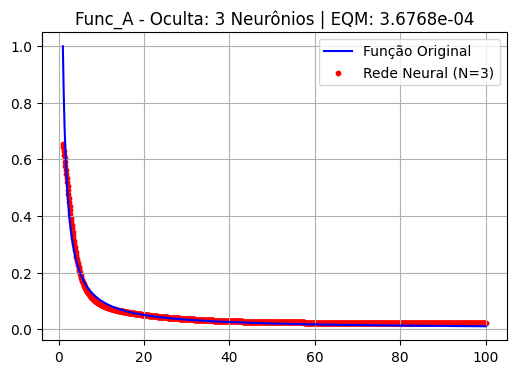

Treinando Func_A com N=4 neurônios...


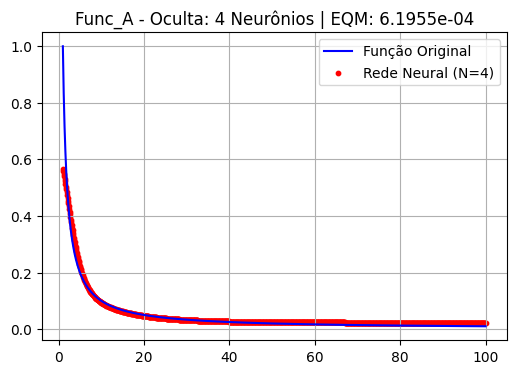

Treinando Func_A com N=5 neurônios...


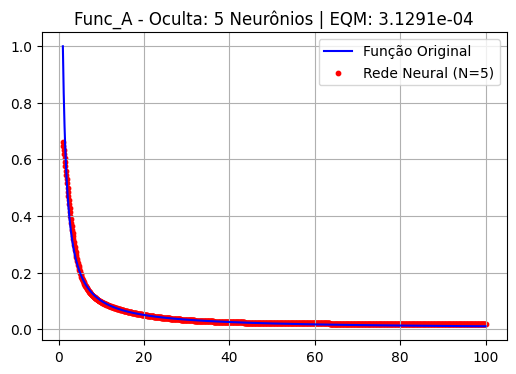

Treinando Func_A com N=10 neurônios...


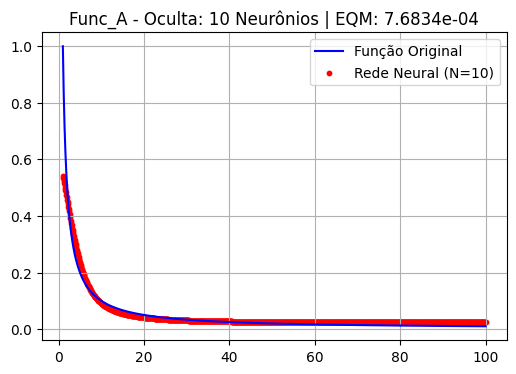

==== FUNÇÃO B ====
Treinando Func_B com N=3 neurônios...


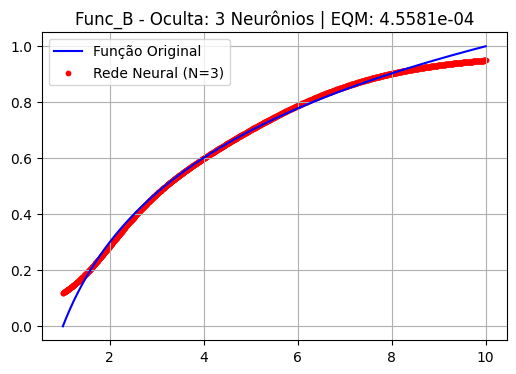

Treinando Func_B com N=4 neurônios...


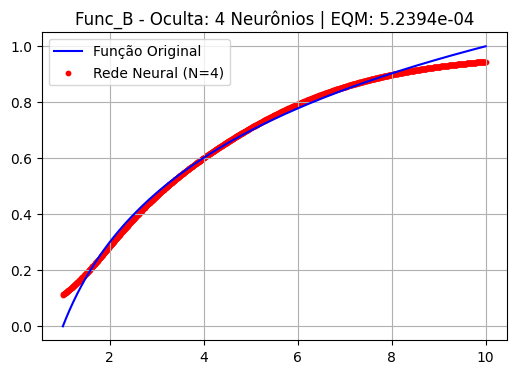

Treinando Func_B com N=5 neurônios...


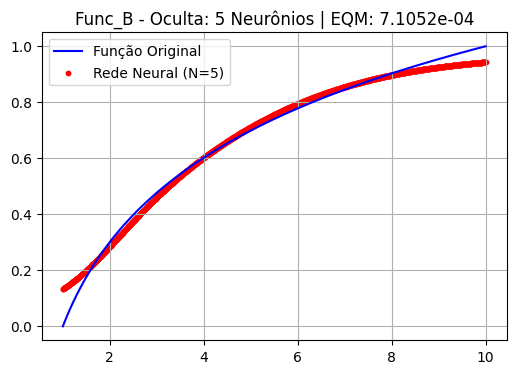

Treinando Func_B com N=10 neurônios...


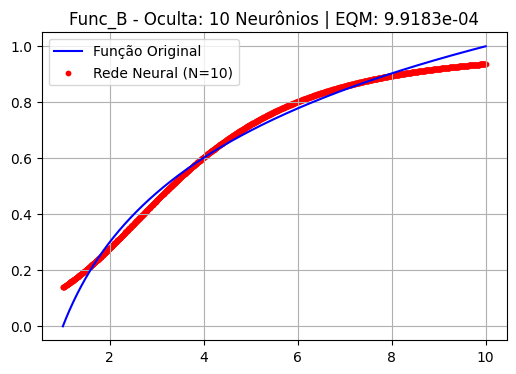

==== FUNÇÃO C ====
Treinando Func_C com N=3 neurônios...


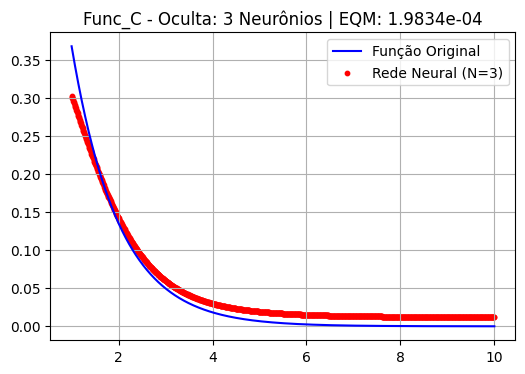

Treinando Func_C com N=4 neurônios...


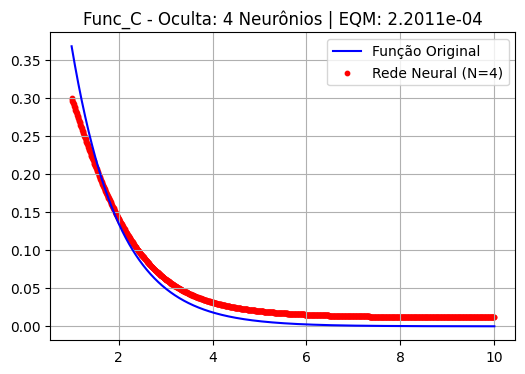

Treinando Func_C com N=5 neurônios...


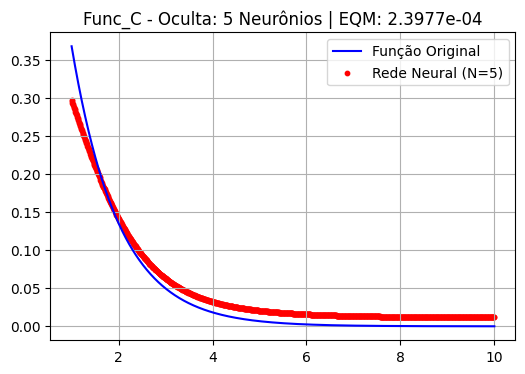

Treinando Func_C com N=10 neurônios...


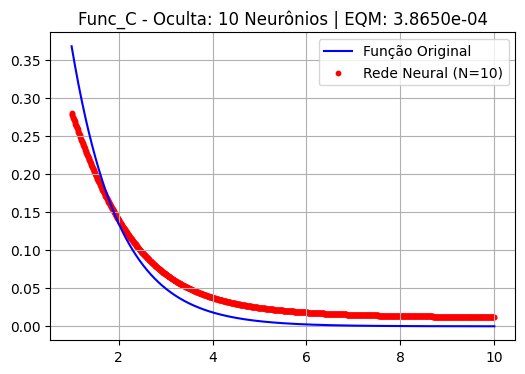

==== FUNÇÃO D ====
Treinando Func_D com N=3 neurônios...


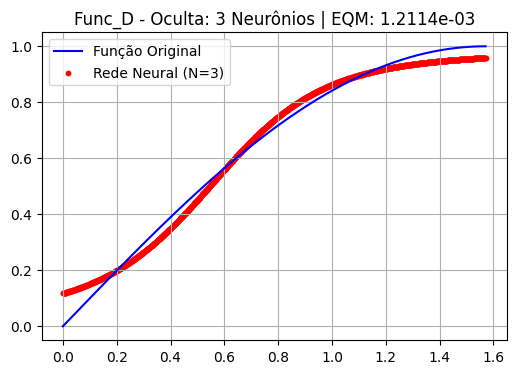

Treinando Func_D com N=4 neurônios...


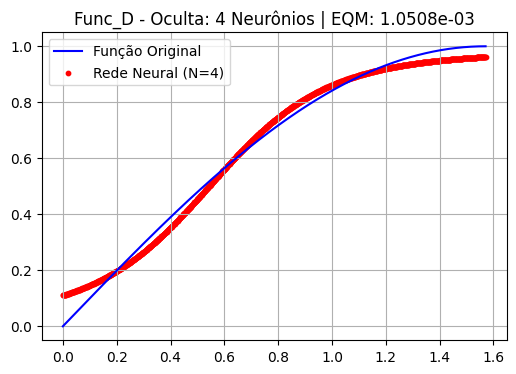

Treinando Func_D com N=5 neurônios...


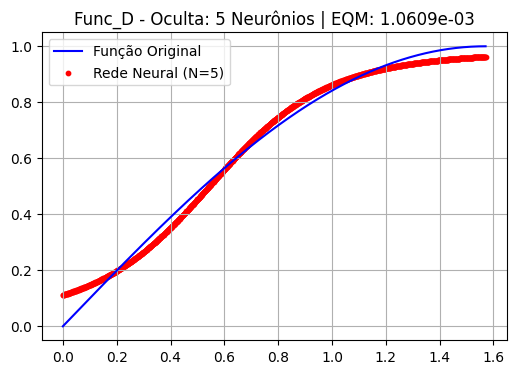

Treinando Func_D com N=10 neurônios...


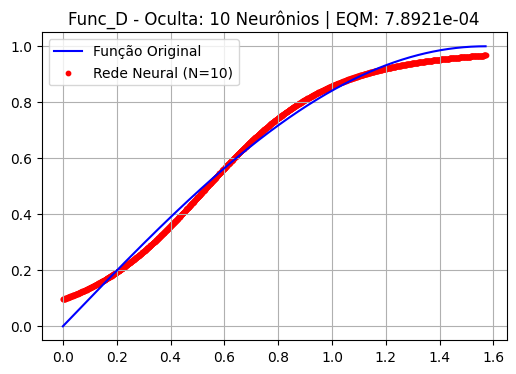

==== FUNÇÃO E ====
Treinando Func_E com N=3 neurônios...


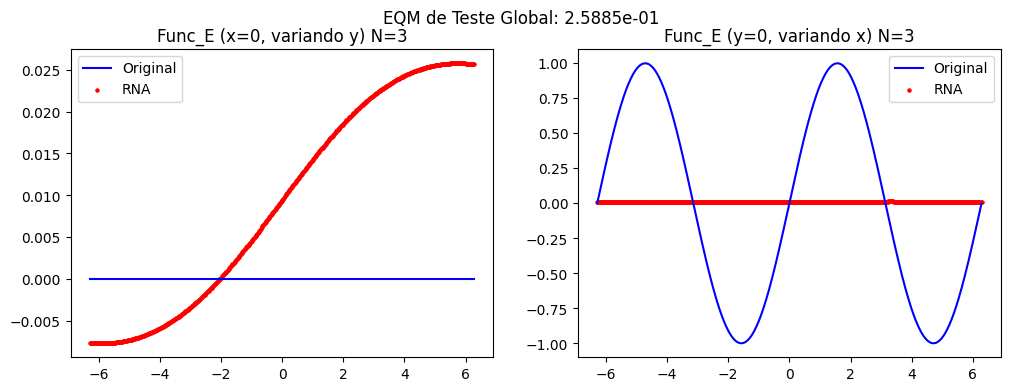

Treinando Func_E com N=4 neurônios...


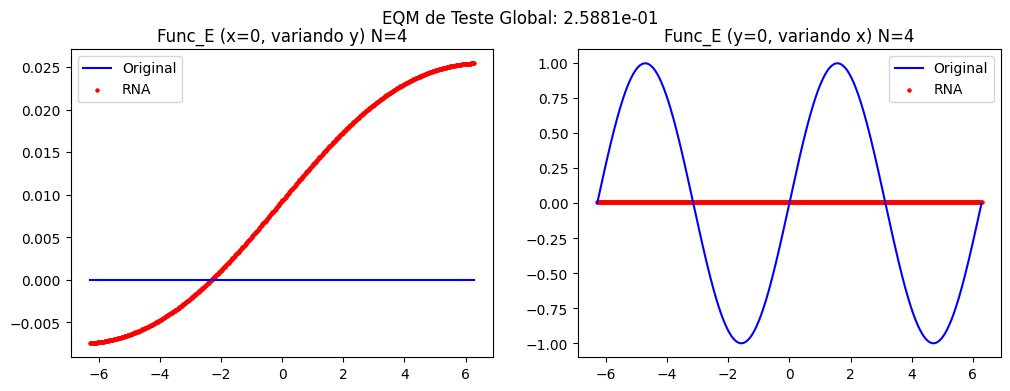

Treinando Func_E com N=5 neurônios...


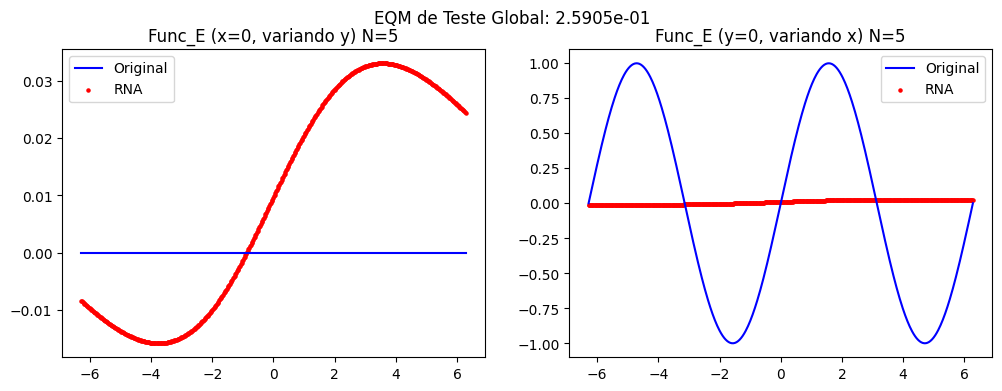

Treinando Func_E com N=10 neurônios...


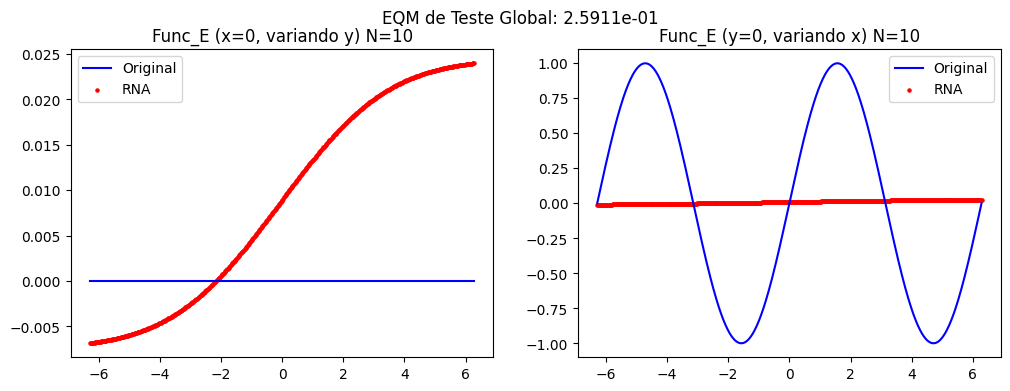

In [7]:
# Célula 5: Rodando experimentos - Redes Pequenas
neuronios_poucos = [3, 4, 5, 10]
epocas_padrao = 15000
eta_padrao = 0.5

print("==== FUNÇÃO A ====")
executar_experimento('Func_A', func_a, [1, 100], neuronios_poucos, eta=eta_padrao, epochs=epocas_padrao)

print("==== FUNÇÃO B ====")
executar_experimento('Func_B', func_b, [1, 10], neuronios_poucos, eta=eta_padrao, epochs=epocas_padrao)

print("==== FUNÇÃO C ====")
executar_experimento('Func_C', func_c, [1, 10], neuronios_poucos, eta=eta_padrao, epochs=epocas_padrao)

print("==== FUNÇÃO D ====")
executar_experimento('Func_D', func_d, [0, np.pi/2], neuronios_poucos, eta=eta_padrao, epochs=epocas_padrao)

print("==== FUNÇÃO E ====")
executar_experimento('Func_E', func_e, [-2*np.pi, 2*np.pi], neuronios_poucos, eta=eta_padrao, epochs=epocas_padrao, is_2d=True, normalizar_e=True)

==== FUNÇÃO A ====
Treinando Func_A com N=15 neurônios...


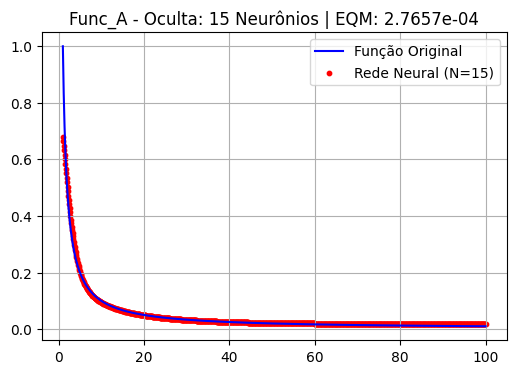

Treinando Func_A com N=20 neurônios...


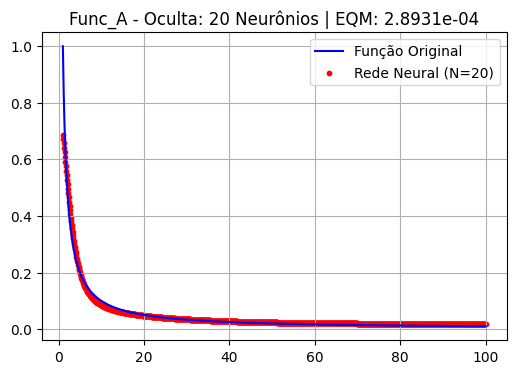

Treinando Func_A com N=50 neurônios...


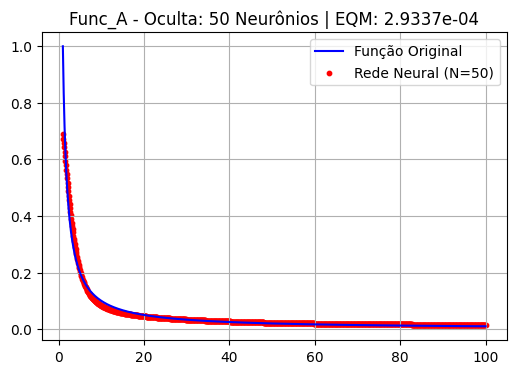

Treinando Func_A com N=100 neurônios...


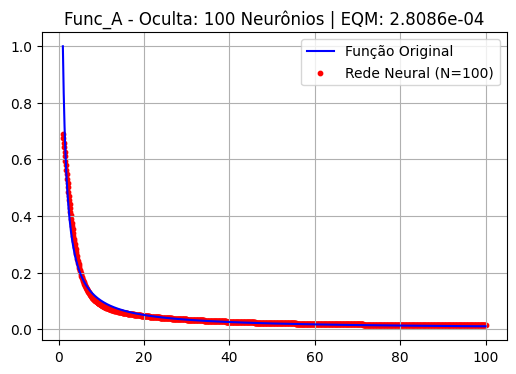

In [9]:
# Célula 6: Rodando experimentos - Redes Grandes
neuronios_muitos = [15, 20, 50, 100]

print("==== FUNÇÃO A ====")
executar_experimento('Func_A', func_a, [1, 100], neuronios_muitos, eta=eta_padrao, epochs=epocas_padrao)




==== FUNÇÃO B ====
Treinando Func_B com N=15 neurônios...


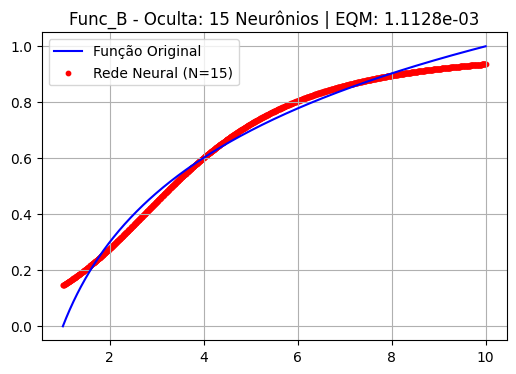

Treinando Func_B com N=20 neurônios...


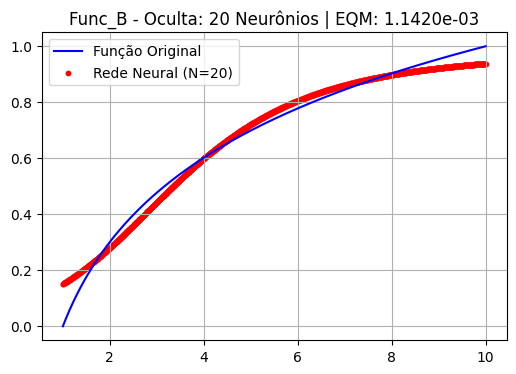

Treinando Func_B com N=50 neurônios...


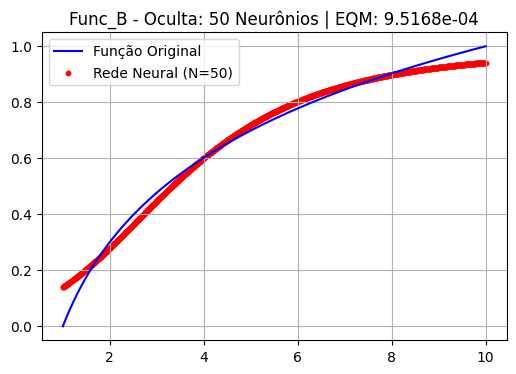

Treinando Func_B com N=100 neurônios...


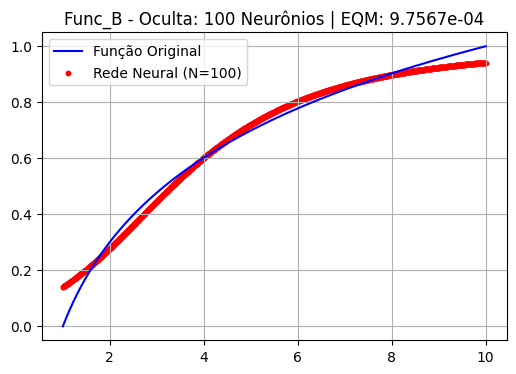

In [10]:
print("==== FUNÇÃO B ====")
executar_experimento('Func_B', func_b, [1, 10], neuronios_muitos, eta=eta_padrao, epochs=epocas_padrao)


==== FUNÇÃO C ====
Treinando Func_C com N=15 neurônios...


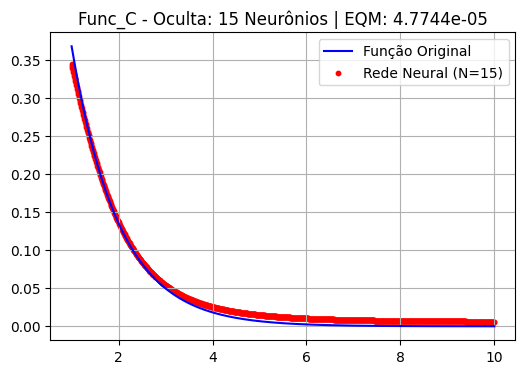

Treinando Func_C com N=20 neurônios...


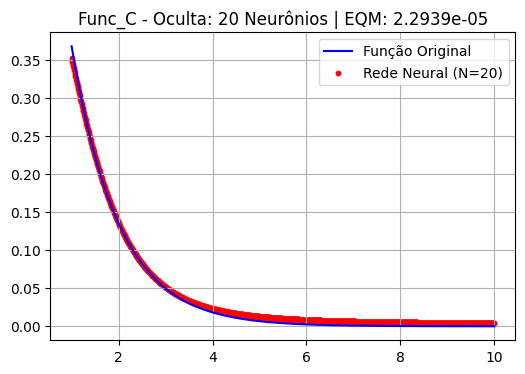

Treinando Func_C com N=50 neurônios...


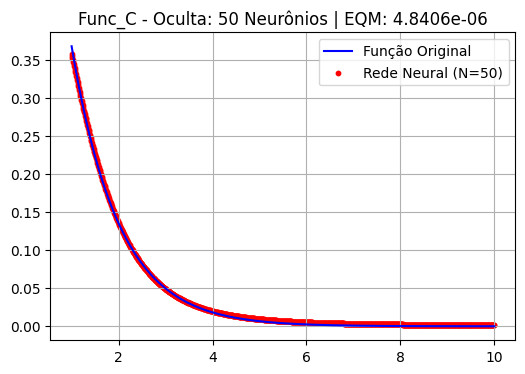

Treinando Func_C com N=100 neurônios...


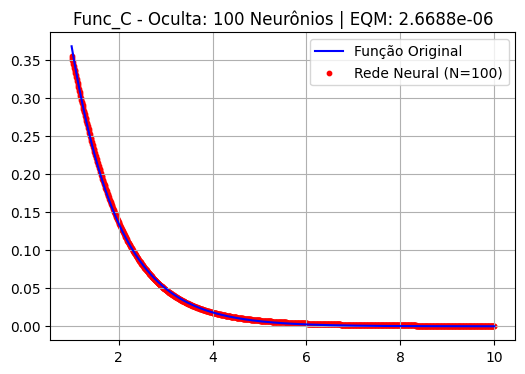

In [11]:

print("==== FUNÇÃO C ====")
executar_experimento('Func_C', func_c, [1, 10], neuronios_muitos, eta=eta_padrao, epochs=epocas_padrao)


==== FUNÇÃO D ====
Treinando Func_D com N=15 neurônios...


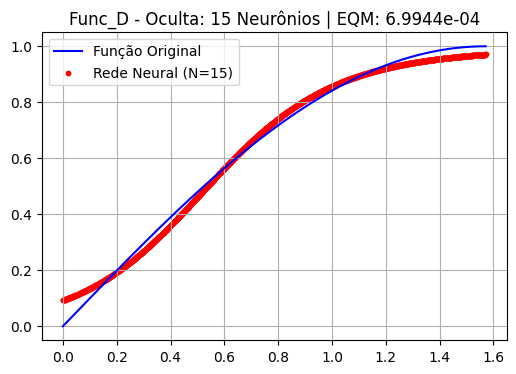

Treinando Func_D com N=20 neurônios...


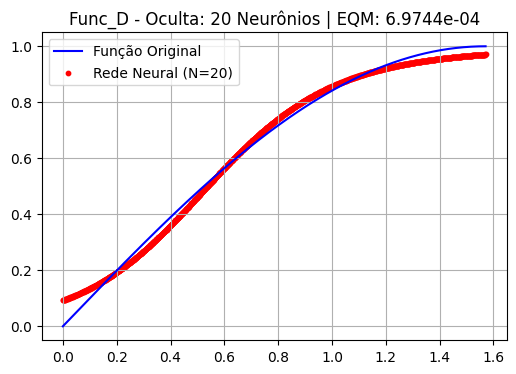

Treinando Func_D com N=50 neurônios...


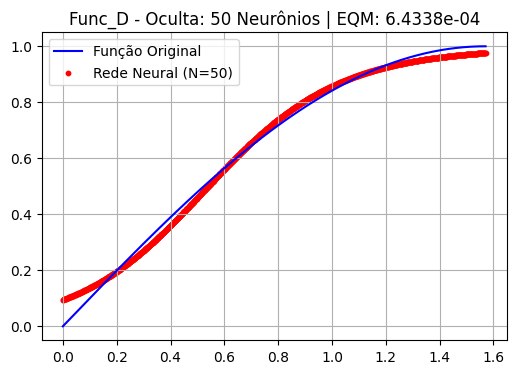

Treinando Func_D com N=100 neurônios...


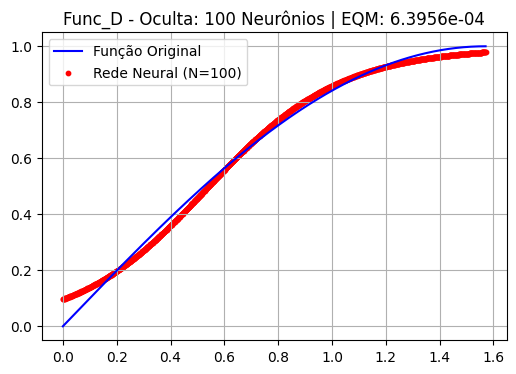

In [12]:

print("==== FUNÇÃO D ====")
executar_experimento('Func_D', func_d, [0, np.pi/2], neuronios_muitos, eta=eta_padrao, epochs=epocas_padrao)

==== FUNÇÃO E ====
Treinando Func_E com N=15 neurônios...


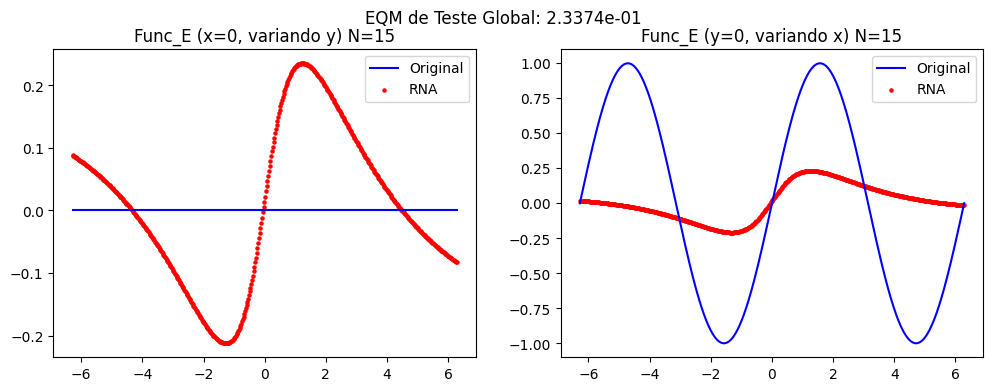

Treinando Func_E com N=20 neurônios...


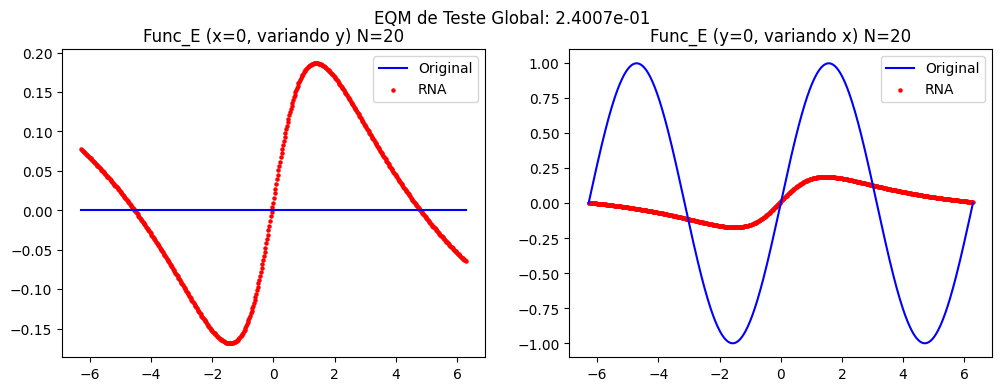

Treinando Func_E com N=50 neurônios...


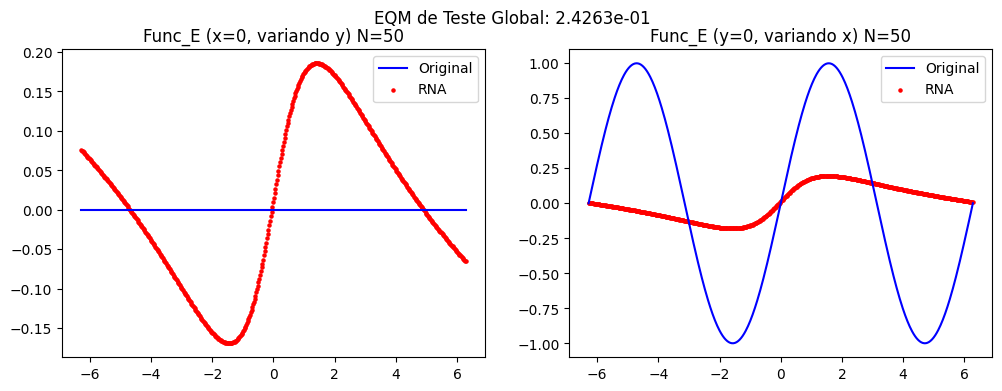

Treinando Func_E com N=100 neurônios...


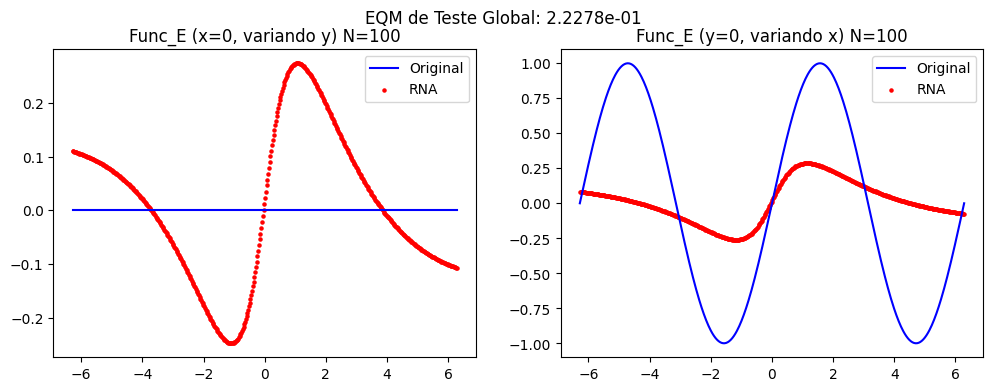

In [8]:

print("==== FUNÇÃO E ====")
executar_experimento('Func_E', func_e, [-2*np.pi, 2*np.pi], neuronios_muitos, eta=eta_padrao, epochs=epocas_padrao, is_2d=True, normalizar_e=True)

,Func_A (1/x),Func_B (log10),Func_C (exp(-x)),Func_D (sen(x)),Func_E (sen(x)cos(y))
N_Neurônios,,,,,
3,3.6768e-04,4.5581e-04,1.9834e-04,1.2114e-03,2.5885e-01
4,6.1955e-04,5.2394e-04,2.2011e-04,1.0508e-03,2.5881e-01
5,3.1291e-04,7.1052e-04,2.3977e-04,1.0609e-03,2.5905e-01
10,7.6834e-04,9.9183e-04,3.8650e-04,7.8921e-04,2.5911e-01
15,2.7657e-04,1.1128e-03,4.7744e-05,6.9944e-04,2.3374e-01
20,2.8931e-04,1.1420e-03,2.2939e-05,6.9744e-04,2.4007e-01
50,2.9337e-04,9.5168e-04,4.8406e-06,6.4338e-04,2.4263e-01
100,2.8086e-04,9.7567e-04,2.6688e-06,6.3956e-04,2.2278e-01


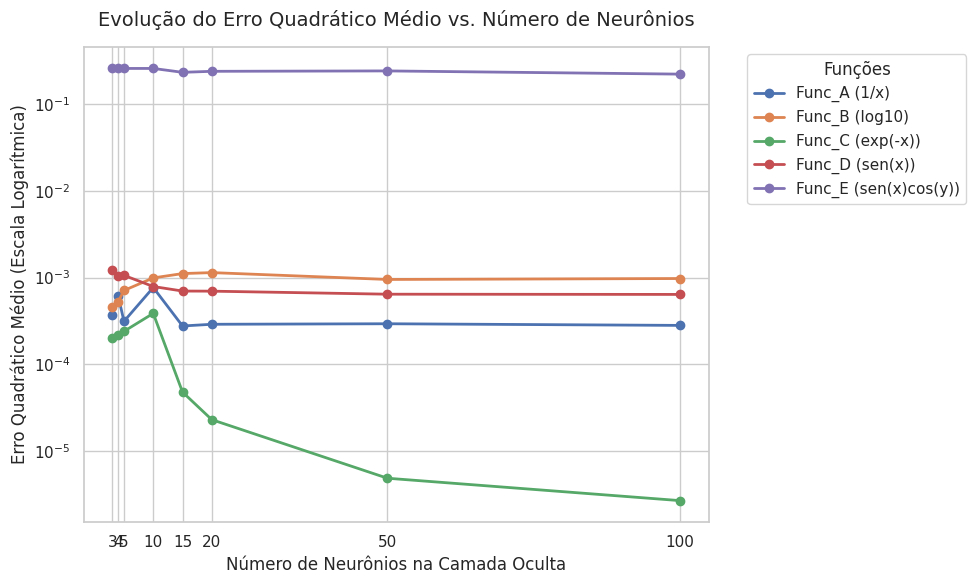

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Organizando os dados extraídos das suas imagens
dados_eqm = {
    'N_Neurônios': [3, 4, 5, 10, 15, 20, 50, 100],
    'Func_A (1/x)': [3.6768e-04, 6.1955e-04, 3.1291e-04, 7.6834e-04, 2.7657e-04, 2.8931e-04, 2.9337e-04, 2.8086e-04],
    'Func_B (log10)': [4.5581e-04, 5.2394e-04, 7.1052e-04, 9.9183e-04, 1.1128e-03, 1.1420e-03, 9.5168e-04, 9.7567e-04],
    'Func_C (exp(-x))': [1.9834e-04, 2.2011e-04, 2.3977e-04, 3.8650e-04, 4.7744e-05, 2.2939e-05, 4.8406e-06, 2.6688e-06],
    'Func_D (sen(x))': [1.2114e-03, 1.0508e-03, 1.0609e-03, 7.8921e-04, 6.9944e-04, 6.9744e-04, 6.4338e-04, 6.3956e-04],
    'Func_E (sen(x)cos(y))': [2.5885e-01, 2.5881e-01, 2.5905e-01, 2.5911e-01, 2.3374e-01, 2.4007e-01, 2.4263e-01, 2.2278e-01]
}

# 2. Criando o DataFrame
df_eqm = pd.DataFrame(dados_eqm)
df_eqm.set_index('N_Neurônios', inplace=True)

# 3. Exibindo a Tabela Formatada no Jupyter
# O '_r' em 'Blues_r' inverte o mapa de cores: menor erro = azul escuro / maior erro = azul claro ou branco
display(df_eqm.style.background_gradient(cmap='Blues_r', axis=0)
             .format("{:.4e}")
             .set_caption("Tabela de Erro Quadrático Médio (EQM) por Função e Nº de Neurônios"))


# 4. Criando o Gráfico Comparativo
plt.figure(figsize=(10, 6))

# Usando um estilo mais limpo
sns.set_theme(style="whitegrid")

# Plotando as linhas
for coluna in df_eqm.columns:
    plt.plot(df_eqm.index, df_eqm[coluna], marker='o', linewidth=2, markersize=6, label=coluna)

# Configurações do gráfico
plt.title('Evolução do Erro Quadrático Médio vs. Número de Neurônios', fontsize=14, pad=15)
plt.xlabel('Número de Neurônios na Camada Oculta', fontsize=12)
plt.ylabel('Erro Quadrático Médio (Escala Logarítmica)', fontsize=12)
plt.yscale('log') # Fundamental para visualizar escalas tão diferentes
plt.xticks(df_eqm.index)
plt.legend(title='Funções', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Renderiza
plt.show()